In [64]:
import kagglehub


path = kagglehub.dataset_download("tobiasbueck/multilingual-customer-support-tickets")

print("Path to dataset files:", path)


Path to dataset files: /home/hello/.cache/kagglehub/datasets/tobiasbueck/multilingual-customer-support-tickets/versions/14


In [30]:
import pandas as pd 

df = pd.read_csv("data/tickets-dataset.csv")
df.head(2)

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28587 entries, 0 to 28586
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   subject   24749 non-null  str  
 1   body      28587 non-null  str  
 2   answer    28580 non-null  str  
 3   type      28587 non-null  str  
 4   queue     28587 non-null  str  
 5   priority  28587 non-null  str  
 6   language  28587 non-null  str  
 7   version   28587 non-null  int64
 8   tag_1     28587 non-null  str  
 9   tag_2     28574 non-null  str  
 10  tag_3     28451 non-null  str  
 11  tag_4     25529 non-null  str  
 12  tag_5     14545 non-null  str  
 13  tag_6     5874 non-null   str  
 14  tag_7     2040 non-null   str  
 15  tag_8     565 non-null    str  
dtypes: int64(1), str(15)
memory usage: 3.5 MB


In [32]:
df.shape

(28587, 16)

In [33]:
df["language"].value_counts()

language
en    16338
de    12249
Name: count, dtype: int64

In [34]:
df.isnull().sum()

subject      3838
body            0
answer          7
type            0
queue           0
priority        0
language        0
version         0
tag_1           0
tag_2          13
tag_3         136
tag_4        3058
tag_5       14042
tag_6       22713
tag_7       26547
tag_8       28022
dtype: int64

In [35]:
df["subject"] = df["subject"].fillna("")

In [36]:
df = df.dropna(subset=['body'])

In [37]:
df = df[df["language"]== "en"]

In [38]:
df["text"] = df["subject"]+" "+df["body"]

In [39]:
df.isnull().sum()

subject         0
body            0
answer          3
type            0
queue           0
priority        0
language        0
version         0
tag_1           0
tag_2           6
tag_3          69
tag_4        1711
tag_5        7922
tag_6       12968
tag_7       15204
tag_8       16057
text            0
dtype: int64

In [40]:
df = df[["text", 'queue','type']] 
df

,text,queue,type
1,"Account Disruption Dear Customer Support Team,...",Technical Support,Incident
2,Query About Smart Home System Integration Feat...,Returns and Exchanges,Request
3,Inquiry Regarding Invoice Details Dear Custome...,Billing and Payments,Request
4,Question About Marketing Agency Software Compa...,Sales and Pre-Sales,Problem
5,"Feature Query Dear Customer Support,\n\nI hope...",Technical Support,Request
...,...,...,...
28578,Problem with Billing Adjustment An unexpected ...,Billing and Payments,Incident
28580,Urgent: Incident Involving Data Breach in Medi...,Product Support,Problem
28582,Performance Problem with Data Analytics Tool T...,Technical Support,Incident
28585,Update Request for SaaS Platform Integration F...,IT Support,Change


In [41]:
df.rename(
    columns = {
        'queue':'category',
        'type':"issuse_type"
    },inplace = True
)

In [42]:
df

,text,category,issuse_type
1,"Account Disruption Dear Customer Support Team,...",Technical Support,Incident
2,Query About Smart Home System Integration Feat...,Returns and Exchanges,Request
3,Inquiry Regarding Invoice Details Dear Custome...,Billing and Payments,Request
4,Question About Marketing Agency Software Compa...,Sales and Pre-Sales,Problem
5,"Feature Query Dear Customer Support,\n\nI hope...",Technical Support,Request
...,...,...,...
28578,Problem with Billing Adjustment An unexpected ...,Billing and Payments,Incident
28580,Urgent: Incident Involving Data Breach in Medi...,Product Support,Problem
28582,Performance Problem with Data Analytics Tool T...,Technical Support,Incident
28585,Update Request for SaaS Platform Integration F...,IT Support,Change


In [43]:
df['category'].value_counts()

category
Technical Support                  4737
Product Support                    3073
Customer Service                   2410
IT Support                         1942
Billing and Payments               1595
Returns and Exchanges               820
Service Outages and Maintenance     664
Sales and Pre-Sales                 513
Human Resources                     348
General Inquiry                     236
Name: count, dtype: int64

It was little bit imbalance , lets deal with it later

In [44]:
df['issuse_type'].value_counts()

issuse_type
Incident    6571
Request     4665
Problem     3397
Change      1705
Name: count, dtype: int64

In [45]:
df.isnull().sum()

text           0
category       0
issuse_type    0
dtype: int64

In [46]:
df['text_length'] = df['text'].apply(len)
df['text_length'].mean()

np.float64(405.5386828253152)

In [47]:
df['text_length'] = df['text'].apply(lambda x: len(x.split()))
print(df['text_length'].mean())

58.64304076386339


In [48]:
df['text'].sample(5)

5773      Customer Support, reporting a critical issue ...
21487    Trouble with Database Connection on PostgreSQL...
7212     Inquiry About Security Capabilities of Healthc...
1857     RapidMiner and Redis Integration Inquiry Custo...
13034    Support Case An unauthorized access incident h...
Name: text, dtype: str

In [49]:
from collections import Counter
all_words = " ".join(df['text']).lower().split()
Counter(all_words).most_common(40)

[('the', 42354),
 ('to', 37197),
 ('and', 30479),
 ('data', 12445),
 ('in', 12123),
 ('for', 12065),
 ('i', 11260),
 ('a', 10618),
 ('you', 10553),
 ('on', 10033),
 ('with', 9359),
 ('we', 9113),
 ('this', 8913),
 ('would', 8286),
 ('our', 7687),
 ('your', 7586),
 ('of', 7470),
 ('is', 7408),
 ('have', 7217),
 ('be', 7020),
 ('could', 6733),
 ('issue', 6047),
 ('customer', 5835),
 ('security', 5804),
 ('are', 5648),
 ('assistance', 5267),
 ('provide', 5238),
 ('appreciate', 5224),
 ('am', 4963),
 ('that', 4946),
 ('software', 4904),
 ('due', 4800),
 ('as', 4751),
 ('digital', 4722),
 ('medical', 4709),
 ('analytics', 4623),
 ('investment', 4549),
 ('support', 4338),
 ('please', 4321),
 ('about', 4299)]

In [50]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re

all_stop_words = ENGLISH_STOP_WORDS.union(['hi', 'hello', 'thanks', 'thank', 'regards', 'dear'])


In [51]:
def remove_stopwords(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z]"," ",text)
    words = text.split()
    words = [w for w in words if w not in all_stop_words and len(w) > 2]
    return " ".join(words)

df["clean_text"] = df['text'].apply(remove_stopwords)
df['clean_text']
    

1        account disruption customer support team writi...
2        query smart home integration features customer...
3        inquiry regarding invoice details customer sup...
4        question marketing agency software compatibili...
5        feature query customer support hope message re...
                               ...                        
28578    problem billing adjustment unexpected billing ...
28580    urgent incident involving data breach medical ...
28582    performance problem data analytics tool data a...
28585    update request saas platform integration featu...
28586    inquiry project management features looking de...
Name: clean_text, Length: 16338, dtype: str

In [52]:
df

,text,category,issuse_type,text_length,clean_text
1,"Account Disruption Dear Customer Support Team,...",Technical Support,Incident,84,account disruption customer support team writi...
2,Query About Smart Home System Integration Feat...,Returns and Exchanges,Request,83,query smart home integration features customer...
3,Inquiry Regarding Invoice Details Dear Custome...,Billing and Payments,Request,95,inquiry regarding invoice details customer sup...
4,Question About Marketing Agency Software Compa...,Sales and Pre-Sales,Problem,103,question marketing agency software compatibili...
5,"Feature Query Dear Customer Support,\n\nI hope...",Technical Support,Request,99,feature query customer support hope message re...
...,...,...,...,...,...
28578,Problem with Billing Adjustment An unexpected ...,Billing and Payments,Incident,21,problem billing adjustment unexpected billing ...
28580,Urgent: Incident Involving Data Breach in Medi...,Product Support,Problem,21,urgent incident involving data breach medical ...
28582,Performance Problem with Data Analytics Tool T...,Technical Support,Incident,16,performance problem data analytics tool data a...
28585,Update Request for SaaS Platform Integration F...,IT Support,Change,48,update request saas platform integration featu...


ok... Lets find Keywords belonging to the category

In [53]:
def find_keywords():
    for item in df['category'].unique():
        print(f"Category : {item}")
        subset = df[df['category']== item]
        words = " ".join(subset['clean_text']).lower().split()
        common = Counter(words).most_common(60)
        print(common)
        # print("\n")

find_keywords()

Category : Technical Support
[('data', 4120), ('issue', 2940), ('support', 2365), ('software', 2206), ('assistance', 2018), ('problem', 1949), ('security', 1862), ('customer', 1534), ('analytics', 1442), ('appreciate', 1439), ('issues', 1423), ('medical', 1367), ('integration', 1327), ('provide', 1314), ('resolve', 1260), ('information', 1228), ('digital', 1169), ('investment', 1152), ('recent', 1107), ('marketing', 1105), ('project', 1085), ('updates', 1047), ('tools', 1036), ('matter', 1014), ('access', 1010), ('platform', 1001), ('greatly', 987), ('systems', 945), ('management', 918), ('team', 886), ('saas', 861), ('restarting', 860), ('guidance', 845), ('breach', 793), ('performance', 786), ('problems', 776), ('persists', 730), ('despite', 727), ('steps', 721), ('hospital', 717), ('network', 697), ('server', 693), ('possible', 672), ('request', 667), ('strategies', 664), ('devices', 654), ('help', 644), ('soon', 626), ('look', 621), ('resolving', 621), ('solution', 602), ('efforts'

There are many corpus-level stopwords. 

In [54]:
custom_stopwords = set([
    'data','support','issue','issues','information','provide','request',
    'assistance','customer','appreciate','regards','thanks','thank',
    'dear','team','help','looking','forward','greatly','soon','problem','greatly','great','problems'
])

all_stop_words = ENGLISH_STOP_WORDS.union(custom_stopwords)

In [55]:
df["clean_text"] = df['text'].apply(remove_stopwords)
df['clean_text']  

1        account disruption writing report significant ...
2        query smart home integration features hope mes...
3        inquiry regarding invoice details hope message...
4        question marketing agency software compatibili...
5        feature query hope message reaches good health...
                               ...                        
28578    billing adjustment unexpected billing discrepa...
28580    urgent incident involving breach medical recor...
28582    performance analytics tool analytics tool expe...
28585    update saas platform integration features requ...
28586    inquiry project management features detailed p...
Name: clean_text, Length: 16338, dtype: str

In [56]:
find_keywords()

Category : Technical Support
[('software', 2206), ('security', 1862), ('analytics', 1442), ('medical', 1367), ('integration', 1327), ('resolve', 1260), ('digital', 1169), ('investment', 1152), ('recent', 1107), ('marketing', 1105), ('project', 1085), ('updates', 1047), ('tools', 1036), ('matter', 1014), ('access', 1010), ('platform', 1001), ('systems', 945), ('management', 918), ('saas', 861), ('restarting', 860), ('guidance', 845), ('breach', 793), ('performance', 786), ('persists', 730), ('despite', 727), ('steps', 721), ('hospital', 717), ('network', 697), ('server', 693), ('possible', 672), ('strategies', 664), ('devices', 654), ('look', 621), ('resolving', 621), ('solution', 602), ('efforts', 573), ('need', 572), ('facing', 559), ('potential', 558), ('brand', 538), ('know', 524), ('attempts', 488), ('measures', 485), ('updating', 485), ('cause', 483), ('update', 480), ('troubleshooting', 468), ('compatibility', 458), ('impacting', 458), ('integrating', 448), ('incident', 448), ('r

In [57]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features = 5000)

x = vectorizer.fit_transform(df['clean_text'])
y = df['category']
print("{x} ----- {y}")

{x} ----- {y}


In [58]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [59]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 200)
model.fit(x_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [60]:
from sklearn.metrics import classification_report

y_pred = model.predict(x_test)

print(classification_report(y_test, y_pred))

                                 precision    recall  f1-score   support

           Billing and Payments       0.86      0.67      0.75       301
               Customer Service       0.38      0.35      0.37       496
                General Inquiry       1.00      0.05      0.10        37
                Human Resources       1.00      0.12      0.21        68
                     IT Support       0.43      0.23      0.30       362
                Product Support       0.38      0.41      0.40       620
          Returns and Exchanges       0.79      0.11      0.19       175
            Sales and Pre-Sales       0.79      0.09      0.16       127
Service Outages and Maintenance       0.84      0.54      0.66       161
              Technical Support       0.44      0.75      0.56       921

                       accuracy                           0.47      3268
                      macro avg       0.69      0.33      0.37      3268
                   weighted avg       0.53      0

In [ ]:
import pickle
pickle.dump(model, open("models/category_model.pkl",'wb'))
pickle.dump(vectorizer,open('models/vectorizer.pkl','wb'))

In [62]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np


In [63]:
le_category   = LabelEncoder()
le_issue_type = LabelEncoder()

In [64]:
df['category_enc']   = le_category.fit_transform(df['category'])
df['issue_type_enc'] = le_issue_type.fit_transform(df['issuse_type'])

print("Category classes:",   list(le_category.classes_))
print("Issue type classes:", list(le_issue_type.classes_))

Category classes: ['Billing and Payments', 'Customer Service', 'General Inquiry', 'Human Resources', 'IT Support', 'Product Support', 'Returns and Exchanges', 'Sales and Pre-Sales', 'Service Outages and Maintenance', 'Technical Support']
Issue type classes: ['Change', 'Incident', 'Problem', 'Request']


In [65]:
df

,text,category,issuse_type,text_length,clean_text,category_enc,issue_type_enc
1,"Account Disruption Dear Customer Support Team,...",Technical Support,Incident,84,account disruption writing report significant ...,9,1
2,Query About Smart Home System Integration Feat...,Returns and Exchanges,Request,83,query smart home integration features hope mes...,6,3
3,Inquiry Regarding Invoice Details Dear Custome...,Billing and Payments,Request,95,inquiry regarding invoice details hope message...,0,3
4,Question About Marketing Agency Software Compa...,Sales and Pre-Sales,Problem,103,question marketing agency software compatibili...,7,2
5,"Feature Query Dear Customer Support,\n\nI hope...",Technical Support,Request,99,feature query hope message reaches good health...,9,3
...,...,...,...,...,...,...,...
28578,Problem with Billing Adjustment An unexpected ...,Billing and Payments,Incident,21,billing adjustment unexpected billing discrepa...,0,1
28580,Urgent: Incident Involving Data Breach in Medi...,Product Support,Problem,21,urgent incident involving breach medical recor...,5,2
28582,Performance Problem with Data Analytics Tool T...,Technical Support,Incident,16,performance analytics tool analytics tool expe...,9,1
28585,Update Request for SaaS Platform Integration F...,IT Support,Change,48,update saas platform integration features requ...,4,0


In [66]:
cat_counts = df['category'].value_counts()
imbalance_ratio = cat_counts.max()/cat_counts.min()
imbalance_ratio

np.float64(20.072033898305083)

NameError: name 'SMOTE' is not defined

In [72]:
import matplotlib.pyplot as plt

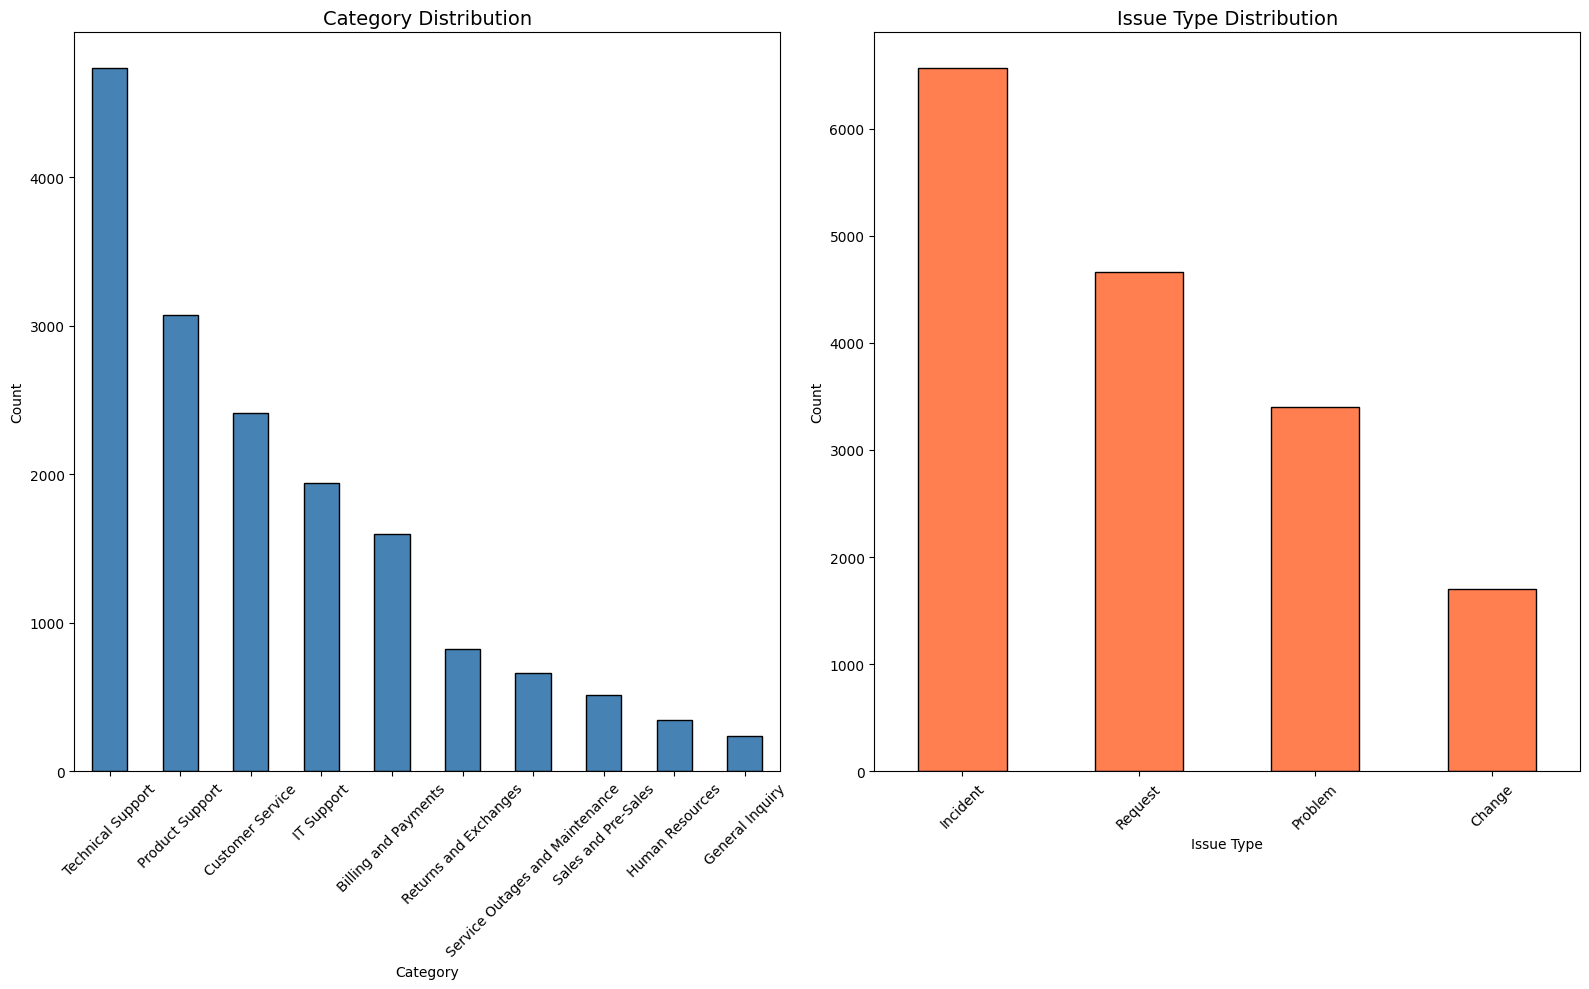

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

df['category'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Category Distribution', fontsize=14)
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Issue Type
df['issuse_type'].value_counts().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='black'
)
axes[1].set_title('Issue Type Distribution', fontsize=14)
axes[1].set_xlabel('Issue Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150)
plt.show()

df

In [80]:
df

,text,category,issuse_type,text_length,clean_text,category_enc,issue_type_enc,word_count
1,"Account Disruption Dear Customer Support Team,...",Technical Support,Incident,84,account disruption writing report significant ...,9,1,84
2,Query About Smart Home System Integration Feat...,Returns and Exchanges,Request,83,query smart home integration features hope mes...,6,3,83
3,Inquiry Regarding Invoice Details Dear Custome...,Billing and Payments,Request,95,inquiry regarding invoice details hope message...,0,3,95
4,Question About Marketing Agency Software Compa...,Sales and Pre-Sales,Problem,103,question marketing agency software compatibili...,7,2,103
5,"Feature Query Dear Customer Support,\n\nI hope...",Technical Support,Request,99,feature query hope message reaches good health...,9,3,99
...,...,...,...,...,...,...,...,...
28578,Problem with Billing Adjustment An unexpected ...,Billing and Payments,Incident,21,billing adjustment unexpected billing discrepa...,0,1,21
28580,Urgent: Incident Involving Data Breach in Medi...,Product Support,Problem,21,urgent incident involving breach medical recor...,5,2,21
28582,Performance Problem with Data Analytics Tool T...,Technical Support,Incident,16,performance analytics tool analytics tool expe...,9,1,16
28585,Update Request for SaaS Platform Integration F...,IT Support,Change,48,update saas platform integration features requ...,4,0,48


In [ ]:
df.drop("text_length",axis = 1)

In [84]:
df['word_count'] = df['clean_text'].apply(lambda x:len(x.split()))

In [85]:
print(df['word_count'].describe())


count    16338.000000
mean        29.161280
std         12.297022
min          1.000000
25%         19.000000
50%         30.000000
75%         39.000000
max         91.000000
Name: word_count, dtype: float64


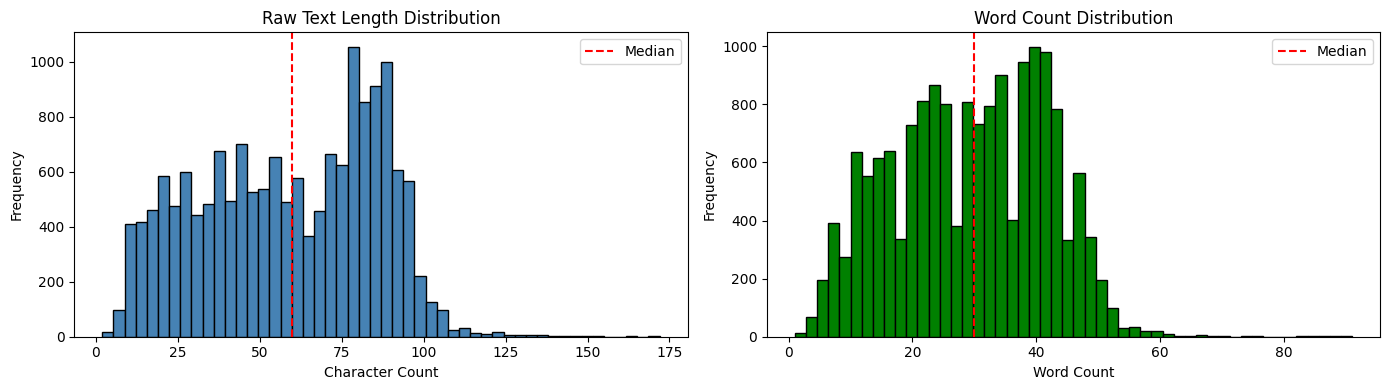

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['text_length'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Raw Text Length Distribution')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['text_length'].median(), color='red', linestyle='--', label='Median')
axes[0].legend()

axes[1].hist(df['word_count'], bins=50, color='green', edgecolor='black')
axes[1].set_title('Word Count Distribution')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['word_count'].median(), color='red', linestyle='--', label='Median')
axes[1].legend()

plt.tight_layout()

In [88]:
import seaborn as sns

/tmp/ipykernel_105959/993835409.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='word_count', palette='Set2')


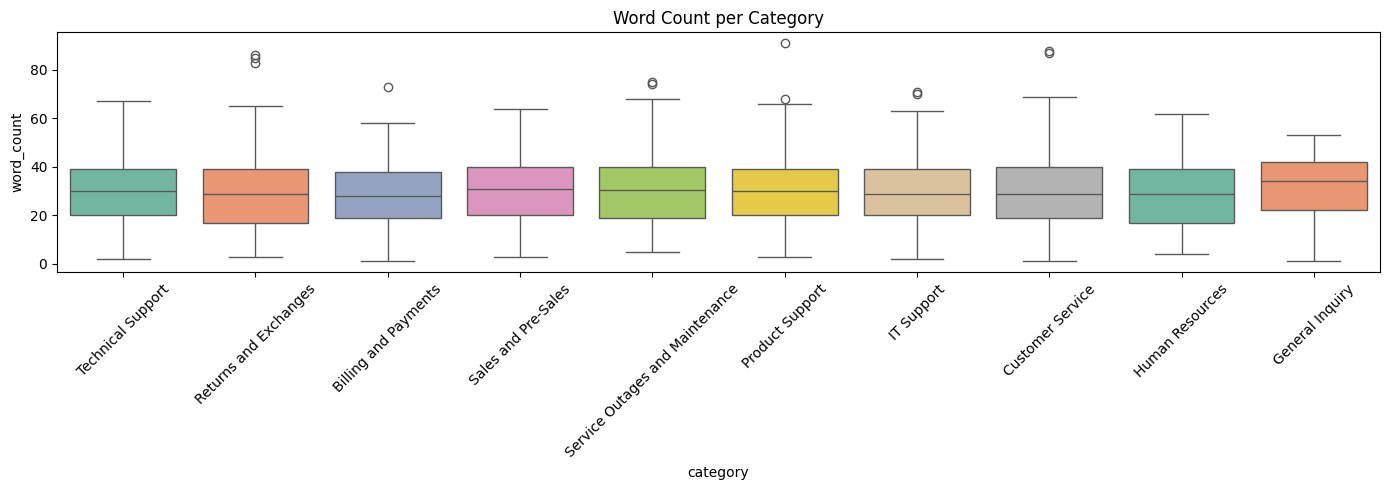

In [89]:
# ── Text length per category (boxplot) ───────────────────────────
plt.figure(figsize=(14, 5))
sns.boxplot(data=df, x='category', y='word_count', palette='Set2')
plt.title('Word Count per Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('eda_wordcount_per_category.png', dpi=150)
plt.show()

In [91]:
# ── Category imbalance ───────────────────────────────────────────
cat_counts = df['category'].value_counts()
cat_pct    = (cat_counts / len(df) * 100).round(2)

imbalance_df = pd.DataFrame({
    'Count':      cat_counts,
    'Percentage': cat_pct
})
print("=== CATEGORY IMBALANCE CHECK ===")
print(imbalance_df)

# Flag if any class < 5% — needs oversampling
minority = imbalance_df[imbalance_df['Percentage'] < 5]
if not minority.empty:
    print(f"\n⚠️  WARNING: {len(minority)} minority class(es) detected — consider SMOTE or oversampling!")
    print(minority)
else:
    print("\n✅ No severe class imbalance detected.")

# ── Issue type imbalance ─────────────────────────────────────────
type_counts = df['issuse_type'].value_counts()
type_pct    = (type_counts / len(df) * 100).round(2)
print("\n=== ISSUE TYPE IMBALANCE CHECK ===")
print(pd.DataFrame({'Count': type_counts, 'Percentage': type_pct}))

=== CATEGORY IMBALANCE CHECK ===
                                 Count  Percentage
category                                          
Technical Support                 4737       28.99
Product Support                   3073       18.81
Customer Service                  2410       14.75
IT Support                        1942       11.89
Billing and Payments              1595        9.76
Returns and Exchanges              820        5.02
Service Outages and Maintenance    664        4.06
Sales and Pre-Sales                513        3.14
Human Resources                    348        2.13
General Inquiry                    236        1.44

⚠️  WARNING: 4 minority class(es) detected — consider SMOTE or oversampling!
                                 Count  Percentage
category                                          
Service Outages and Maintenance    664        4.06
Sales and Pre-Sales                513        3.14
Human Resources                    348        2.13
General Inquiry       

In [92]:
df["clean_word_count"] = df['clean_text'].apply(lambda x: len(str(x).split()))
empty_after_clean = df[df['clean_word_count'] == 0]
print(f"Rows with empty clean_text: {len(empty_after_clean)}")


Rows with empty clean_text: 0


In [93]:
very_short = df[df['clean_word_count'] <= 2]
print(f"Rows with ≤ 2 words after cleaning: {len(very_short)}")
print(very_short[['text', 'clean_text', 'category']].head(10))

Rows with ≤ 2 words after cleaning: 13
                                                    text  \
1547                 Issue Encountered Assistance Needed   
4696                            Problems with the server   
5423                       Several products are impacted   
6245                      Several products are impacted.   
7031            Several products are experiencing issues   
10111                                 Hello support team   
15883                       Seek assistance with billing   
16235                    Seeking assistance with billing   
19025   Could you please assist me? I need help with ...   
19092                   Issues with software integration   

                  clean_text              category  
1547      encountered needed     Technical Support  
4696                  server       General Inquiry  
5423       products impacted     Technical Support  
6245       products impacted     Technical Support  
7031   products experiencing     Te

In [96]:
very_short[['text','category','clean_text']]

,text,category,clean_text
1547,Issue Encountered Assistance Needed,Technical Support,encountered needed
4696,Problems with the server,General Inquiry,server
5423,Several products are impacted,Technical Support,products impacted
6245,Several products are impacted.,Technical Support,products impacted
7031,Several products are experiencing issues,Technical Support,products experiencing
10111,Hello support team,Customer Service,hello
15883,Seek assistance with billing,Billing and Payments,seek billing
16235,Seeking assistance with billing,Billing and Payments,seeking billing
19025,Could you please assist me? I need help with ...,IT Support,assist need
19092,Issues with software integration,Technical Support,software integration


In [99]:
# ── Print everything in one clean summary ─────────────────────────
print("=" * 55)
print("         SMARTTICKET EDA SUMMARY REPORT")
print("=" * 55)
print(f"  Total records          : {len(df)}")
print(f"  Unique categories      : {df['category'].nunique()}")
print(f"  Unique issue types     : {df['issuse_type'].nunique()}")
print(f"  Avg word count (raw)   : {df['word_count'].mean():.1f}")
print(f"  Avg word count (clean) : {df['clean_word_count'].mean():.1f}")
print(f"  Empty rows dropped     : {empty_after_clean.shape[0]}")
print(f"  Duplicate rows         : {df.duplicated().sum()}")
print("=" * 55)
print("\n📊 Category breakdown:")
print(df['category'].value_counts().to_string())
print("\n📊 Issue type breakdown:")
print(df['issuse_type'].value_counts().to_string())

         SMARTTICKET EDA SUMMARY REPORT
  Total records          : 16338
  Unique categories      : 10
  Unique issue types     : 4
  Avg word count (raw)   : 29.2
  Avg word count (clean) : 29.2
  Empty rows dropped     : 0
  Duplicate rows         : 0

📊 Category breakdown:
category
Technical Support                  4737
Product Support                    3073
Customer Service                   2410
IT Support                         1942
Billing and Payments               1595
Returns and Exchanges               820
Service Outages and Maintenance     664
Sales and Pre-Sales                 513
Human Resources                     348
General Inquiry                     236

📊 Issue type breakdown:
issuse_type
Incident    6571
Request     4665
Problem     3397
Change      1705


In [101]:
print("Shape:", df.shape)
print("\nMissing in clean_text:", df['clean_text'].isnull().sum())
print("Missing in category:",   df['category'].isnull().sum())
print("Missing in issue_type:", df['issuse_type'].isnull().sum())

# Check total matches category counts you shared
print("\nTotal rows in category counts:", df['category'].value_counts().sum())

Shape: (16338, 9)

Missing in clean_text: 0
Missing in category: 0
Missing in issue_type: 0

Total rows in category counts: 16338


In [102]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

In [103]:
le_category   = LabelEncoder()
le_issue_type = LabelEncoder()

In [106]:
df['category_enc']   = le_category.fit_transform(df['category'])
df['issue_type_enc'] = le_issue_type.fit_transform(df['issuse_type'])

print("Category classes:",   list(le_category.classes_))
print("Issue type classes:", list(le_issue_type.classes_))

Category classes: ['Billing and Payments', 'Customer Service', 'General Inquiry', 'Human Resources', 'IT Support', 'Product Support', 'Returns and Exchanges', 'Sales and Pre-Sales', 'Service Outages and Maintenance', 'Technical Support']
Issue type classes: ['Change', 'Incident', 'Problem', 'Request']


In [108]:
cat_counts = df['category_enc'].value_counts()
cat_counts


category_enc
9    4737
5    3073
1    2410
4    1942
0    1595
6     820
8     664
7     513
3     348
2     236
Name: count, dtype: int64

if imbalance_ratio > 5.xxxx we need we sample the data to make it balance

In [109]:
imbalance_ratio = cat_counts.max()/cat_counts.min()
imbalance_ratio

np.float64(20.072033898305083)

In [110]:
# from imblearn over_sampling import RandomOverSampler
# ros =RandomOverSampler(random_state=42)

# X_train_res, y_train_res = ros.fit_resample(X_train_tfidf, y_train)
# print(f"Before oversampling: {X_train_tfidf.shape}")
# print(f"After oversampling:  {X_train_res.shape}")


In [112]:
from sklearn.utils.class_weight import compute_class_weight
class_weight_cat = compute_class_weight(
    class_weight ="balanced",
    classes = np.unique(df['category_enc']),
    y = df["category_enc"]
)

In [113]:
class_weight_cat

array([1.02432602, 0.67792531, 6.92288136, 4.69482759, 0.84129763,
       0.53166287, 1.99243902, 3.18479532, 2.46054217, 0.34490184])

In [114]:
class_weight_dict_cat = dict(
    zip(np.unique(df['category_enc']),class_weight_cat)
)
class_weight_dict_cat

{np.int64(0): np.float64(1.0243260188087775),
 np.int64(1): np.float64(0.6779253112033194),
 np.int64(2): np.float64(6.922881355932203),
 np.int64(3): np.float64(4.694827586206896),
 np.int64(4): np.float64(0.84129763130793),
 np.int64(5): np.float64(0.5316628701594533),
 np.int64(6): np.float64(1.992439024390244),
 np.int64(7): np.float64(3.1847953216374267),
 np.int64(8): np.float64(2.460542168674699),
 np.int64(9): np.float64(0.3449018366054465)}

In [121]:
print("Class weights for category:")
for enc,weight in class_weight_dict_cat.items():
    label = le_category.inverse_transform([enc])[0]
    print(f" {enc} -- {label:35s} → weight: {weight:.3f}")

Class weights for category:
 0 -- Billing and Payments                → weight: 1.024
 1 -- Customer Service                    → weight: 0.678
 2 -- General Inquiry                     → weight: 6.923
 3 -- Human Resources                     → weight: 4.695
 4 -- IT Support                          → weight: 0.841
 5 -- Product Support                     → weight: 0.532
 6 -- Returns and Exchanges               → weight: 1.992
 7 -- Sales and Pre-Sales                 → weight: 3.185
 8 -- Service Outages and Maintenance     → weight: 2.461
 9 -- Technical Support                   → weight: 0.345


In [122]:
cat_counts = df['category_enc'].value_counts()
cat_counts

category_enc
9    4737
5    3073
1    2410
4    1942
0    1595
6     820
8     664
7     513
3     348
2     236
Name: count, dtype: int64

Minorirty classes getting the higher class weights

#### STEP 3 — Train / Validation / Test Split


In [124]:
from sklearn.model_selection import train_test_split

x = df['clean_text']
y_cat = df['category_enc']
y_type = df['issue_type_enc']


In [128]:
import pandas as pd 
y = pd.DataFrame({
    'category_enc':y_cat,
    'issue_type_enc':y_type,
})
y

,category_enc,issue_type_enc
1,9,1
2,6,3
3,0,3
4,7,2
5,9,3
...,...,...
28578,0,1
28580,5,2
28582,9,1
28585,4,0


In [129]:
X_train ,X_temp,y_train,y_temp = train_test_split(x,y,random_state=42,test_size=0.30,stratify=y['category_enc'])
X_val ,X_test,y_val,y_test = train_test_split(X_temp,y_temp,random_state=42,test_size=0.50,stratify=y_temp['category_enc'])


In [130]:
print(f"Train size : {len(X_train)}")
print(f"Val size   : {len(X_val)}")
print(f"Test size  : {len(X_test)}")

Train size : 11436
Val size   : 2451
Test size  : 2451


In [131]:
print("\nCategory distribution in train:")
print(pd.Series(le_category.inverse_transform(y_train['category_enc'])).value_counts())


Category distribution in train:
Technical Support                  3316
Product Support                    2151
Customer Service                   1687
IT Support                         1359
Billing and Payments               1116
Returns and Exchanges               574
Service Outages and Maintenance     465
Sales and Pre-Sales                 359
Human Resources                     244
General Inquiry                     165
Name: count, dtype: int64


Now lets apply the sampling balance on the training data

In [133]:
class_weight_cat = compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(y_train['category_enc']),
    y=y_train['category_enc']
)

In [134]:
class_weight_dict_cat = dict(
    zip(np.unique(y_train['category_enc']), class_weight_cat)
)
print("Class weights:")
for enc, weight in class_weight_dict_cat.items():
    label = le_category.inverse_transform([enc])[0]
    print(f"  {label:35s} → {weight:.3f}")


Class weights:
  Billing and Payments                → 1.025
  Customer Service                    → 0.678
  General Inquiry                     → 6.931
  Human Resources                     → 4.687
  IT Support                          → 0.842
  Product Support                     → 0.532
  Returns and Exchanges               → 1.992
  Sales and Pre-Sales                 → 3.186
  Service Outages and Maintenance     → 2.459
  Technical Support                   → 0.345


In [135]:
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier

clf_category = LogisticRegression(
    class_weight = class_weight_dict_cat,
    max_iter = 1000,
    C = 1.0,
    solver = 'lbfgs',
    random_state = 42
)
clf_issue_type = LogisticRegression(
    class_weight = 'balanced',   # only 4 classes, auto balanced
    max_iter     = 1000,
    C            = 1.0,
    solver       = 'lbfgs',
    random_state = 42
)

In [136]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features = 15000,
    ngram_range  = (1, 2),
    min_df       = 3,
    max_df       = 0.90,
    sublinear_tf = True,
) 


In [137]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f"Train matrix : {X_train_tfidf.shape}")
print(f"Val matrix   : {X_val_tfidf.shape}")
print(f"Test matrix  : {X_test_tfidf.shape}")
print(f"Vocabulary   : {len(tfidf.vocabulary_)} words")

Train matrix : (11436, 15000)
Val matrix   : (2451, 15000)
Test matrix  : (2451, 15000)
Vocabulary   : 15000 words


#### Step 5 — Train Both Models Separately


In [138]:
import time 
print("Training category classifier...")
start = time.time()
clf_category.fit(X_train_tfidf,y_train["category_enc"])
print(f"✅ Category model done! ({time.time()-start:.1f}s)")


Training category classifier...
✅ Category model done! (10.2s)


In [139]:
print("\nTraining issue type classifier...")
start = time.time()
clf_issue_type.fit(X_train_tfidf, y_train['issue_type_enc'])
print(f"✅ Issue type model done! ({time.time()-start:.1f}s)")


Training issue type classifier...
✅ Issue type model done! (4.4s)


In [ ]:
from sklearn.metrics import f1_score,confusion_matrix, classification_report

y_val_pred_cat = clf_category.predict(X_val_tfidf)
y_val_pred_type = clf_issue_type.predict(X_val_tfidf)

In [141]:
print(classification_report(
    y_val["category_enc"],
    y_val_pred_cat,
    target_names = le_category.classes_
))

                                 precision    recall  f1-score   support

           Billing and Payments       0.79      0.78      0.78       240
               Customer Service       0.40      0.39      0.39       362
                General Inquiry       0.42      0.66      0.51        35
                Human Resources       0.40      0.69      0.51        52
                     IT Support       0.41      0.48      0.44       291
                Product Support       0.48      0.41      0.44       461
          Returns and Exchanges       0.35      0.49      0.41       123
            Sales and Pre-Sales       0.40      0.66      0.50        77
Service Outages and Maintenance       0.55      0.75      0.64        99
              Technical Support       0.63      0.48      0.55       711

                       accuracy                           0.51      2451
                      macro avg       0.48      0.58      0.52      2451
                   weighted avg       0.52      0

In [142]:
print("=" * 60)
print("   ISSUE TYPE CLASSIFICATION REPORT (Validation)")
print("=" * 60)
print(classification_report(
    y_val['issue_type_enc'],
    y_val_pred_type,
    target_names=le_issue_type.classes_
))

   ISSUE TYPE CLASSIFICATION REPORT (Validation)
              precision    recall  f1-score   support

      Change       0.98      0.98      0.98       252
    Incident       0.88      0.76      0.81      1037
     Problem       0.60      0.77      0.67       471
     Request       0.99      1.00      0.99       691

    accuracy                           0.85      2451
   macro avg       0.86      0.87      0.86      2451
weighted avg       0.87      0.85      0.85      2451



In [143]:
f1_cat  = f1_score(y_val['category_enc'],   y_val_pred_cat,  average='weighted')
f1_type = f1_score(y_val['issue_type_enc'], y_val_pred_type, average='weighted')

print("=" * 60)
print(f"  📊 Weighted F1 — Category   : {f1_cat:.4f}")
print(f"  📊 Weighted F1 — Issue Type : {f1_type:.4f}")
print("=" * 60)

  📊 Weighted F1 — Category   : 0.5086
  📊 Weighted F1 — Issue Type : 0.8542


##### Category — 0.51  Needs fixing

In [144]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [145]:
y_val_pred_cat = clf_category.predict(X_val_tfidf)
cm = confusion_matrix(y_val['category_enc'], y_val_pred_cat)
cm

array([[186,  18,   0,   2,   3,  10,   8,   7,   1,   5],
       [ 15, 142,  10,   7,  36,  51,  31,  19,   8,  43],
       [  0,   1,  23,   0,   6,   1,   1,   1,   0,   2],
       [  3,   3,   0,  36,   3,   2,   4,   0,   1,   0],
       [  6,  30,   7,  12, 139,  20,   9,   6,  15,  47],
       [  6,  62,   9,  14,  43, 190,  26,  17,   6,  88],
       [  9,  15,   0,   2,   5,  16,  60,   3,   2,  11],
       [  0,   8,   1,   1,   1,   8,   4,  51,   3,   0],
       [  0,   9,   0,   0,   6,   3,   1,   0,  74,   6],
       [  9,  69,   5,  15,  98,  98,  27,  24,  24, 342]])

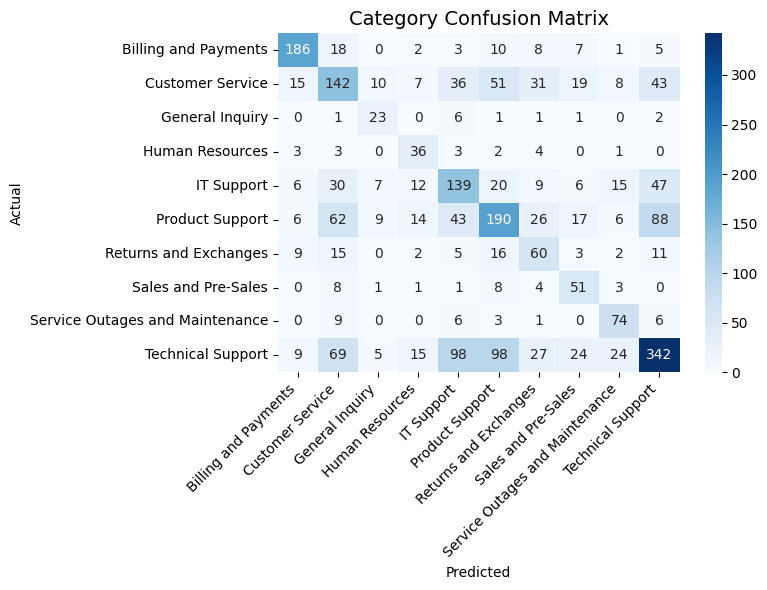

In [148]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True, fmt='d',
    xticklabels=le_category.classes_,
    yticklabels=le_category.classes_,
    cmap='Blues'
)
plt.title('Category Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_category.png', dpi=150)
plt.show()

This will confirm that IT Support, Technical Support, Product Support, Customer Service are being confused with each other.

In [150]:
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer


In [155]:
clf_category_v2 = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features= 20000,
        ngram_range = (1,3),
        min_df= 2,
        max_df = 0.85,
        sublinear_tf = True,
    )),
    ('clf', LinearSVC(
        class_weight = class_weight_dict_cat,
        C = 0.85,
        max_iter = 2000,
        random_state = 42,
    ))
])

In [156]:
clf_category_v2.fit(X_train,y_train['category_enc'])
start = time.time()
print(f"✅ Issue type model done! ({time.time()-start:.1f}s)")

✅ Issue type model done! (0.0s)


In [157]:
y_pred_v2 = clf_category_v2.predict(X_val)

In [158]:
print(classification_report(
    y_val['category_enc'],
    y_pred_v2,
    target_names = le_category.classes_
))

                                 precision    recall  f1-score   support

           Billing and Payments       0.80      0.85      0.82       240
               Customer Service       0.57      0.58      0.57       362
                General Inquiry       0.71      0.71      0.71        35
                Human Resources       0.64      0.71      0.67        52
                     IT Support       0.53      0.59      0.56       291
                Product Support       0.60      0.55      0.57       461
          Returns and Exchanges       0.53      0.58      0.55       123
            Sales and Pre-Sales       0.57      0.58      0.58        77
Service Outages and Maintenance       0.68      0.80      0.73        99
              Technical Support       0.68      0.63      0.65       711

                       accuracy                           0.63      2451
                      macro avg       0.63      0.66      0.64      2451
                   weighted avg       0.63      0

* IT Support            - 0.55 
* Returns and Exchanges - 0.56  

In [161]:
f1_v2 = f1_score(y_val['category_enc'], y_pred_v2, average='weighted')
print(f"Weighted F1 V2: {f1_v2:.4f}")

Weighted F1 V2: 0.6295


Lets Use GridSearchCV

In [163]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline 
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer



In [164]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features = 20000,
        ngram_range  = (1, 3),
        min_df       = 2,
        max_df       = 0.85,
        sublinear_tf = True,
    )),
    ('clf', LinearSVC(
        class_weight = class_weight_dict_cat,
        max_iter     = 2000,
        random_state = 42
    ))
])

In [165]:
param_grid = {
    'clf__C': [0.1, 0.3, 0.5, 1.0, 2.0, 5.0]
}

In [166]:
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv = 5,
    scoring = 'f1_weighted',
    n_jobs = -1,
    verbose = 1
)

In [167]:
grid_search.fit(X_train,y_train['category_enc'])
print(f"Best Parameters__{grid_search.best_params_}")
print(f"✅ Best CV F1    : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameters__{'clf__C': 5.0}
✅ Best CV F1    : 0.6196


In [169]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_val)



print(classification_report(
    y_val['category_enc'],
    y_pred_best,
    target_names=le_category.classes_
))

f1_best = f1_score(y_val['category_enc'], y_pred_best, average='weighted')
print(f" Best Weighted F1: {f1_best:.4f}")

                                 precision    recall  f1-score   support

           Billing and Payments       0.84      0.86      0.85       240
               Customer Service       0.63      0.64      0.64       362
                General Inquiry       0.79      0.63      0.70        35
                Human Resources       0.76      0.65      0.70        52
                     IT Support       0.56      0.61      0.58       291
                Product Support       0.61      0.60      0.60       461
          Returns and Exchanges       0.63      0.58      0.60       123
            Sales and Pre-Sales       0.66      0.57      0.61        77
Service Outages and Maintenance       0.80      0.79      0.80        99
              Technical Support       0.68      0.69      0.69       711

                       accuracy                           0.67      2451
                      macro avg       0.70      0.66      0.68      2451
                   weighted avg       0.67      0

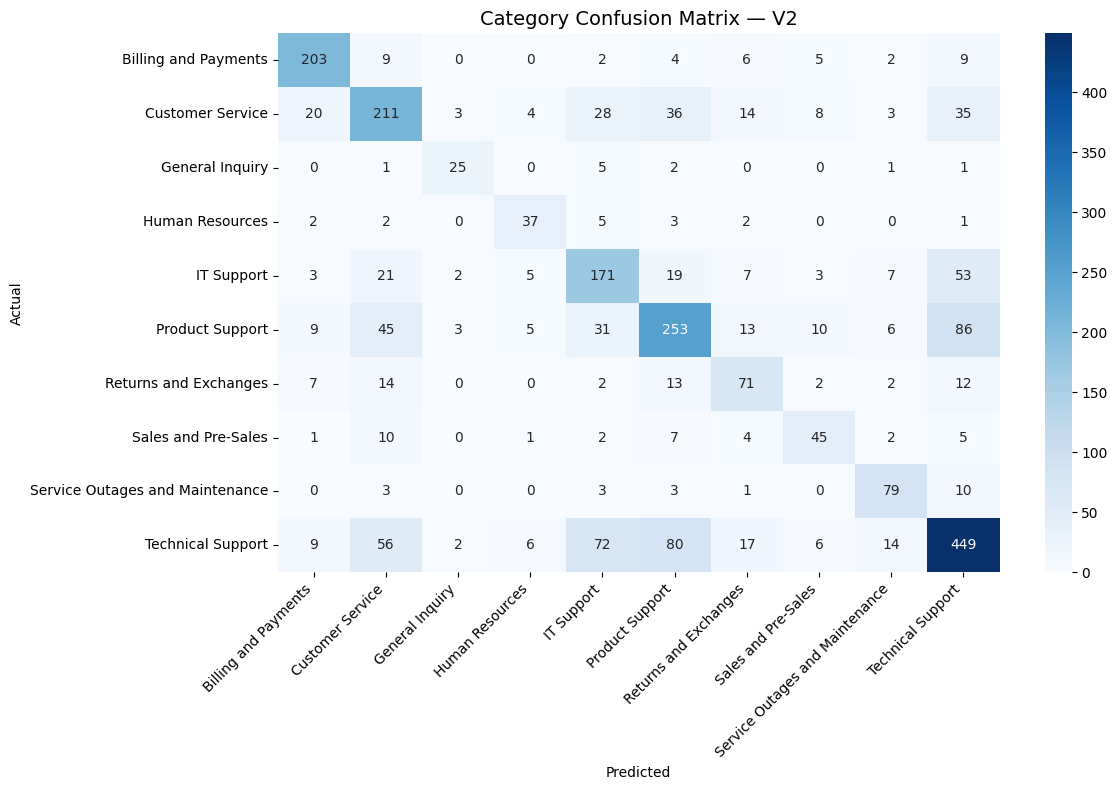

In [170]:
from sklearn.metrics import confusion_matrix
import seaborn as sns, matplotlib.pyplot as plt

cm = confusion_matrix(y_val['category_enc'], y_pred_v2)

plt.figure(figsize=(12, 8))
sns.heatmap(
    cm,
    annot      = True,
    fmt        = 'd',
    cmap       = 'Blues',
    xticklabels = le_category.classes_,
    yticklabels = le_category.classes_
)
plt.title('Category Confusion Matrix — V2', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_v2.png', dpi=150)
plt.show()

In [171]:
# ── Final evaluation on test set (run this now) ───────────────────
y_test_pred_cat  = best_model.predict(X_test)
y_test_pred_type = clf_issue_type.predict(X_test_tfidf)

f1_cat_test  = f1_score(y_test['category_enc'],   y_test_pred_cat,  average='weighted')
f1_type_test = f1_score(y_test['issue_type_enc'],  y_test_pred_type, average='weighted')

print("=" * 50)
print("   FINAL TEST SET SCORES")
print("=" * 50)
print(f"  Category F1   : {f1_cat_test:.4f}")
print(f"  Issue Type F1 : {f1_type_test:.4f}")
print("=" * 50)

   FINAL TEST SET SCORES
  Category F1   : 0.6539
  Issue Type F1 : 0.8497


In [172]:
import joblib, os 
os.makedirs("../models",exist_ok=True)

In [173]:
joblib.dump(best_model,      '../models/clf_category.pkl')

# Save issue type model + its tfidf separately
joblib.dump(clf_issue_type,  '../models/clf_issue_type.pkl')
joblib.dump(tfidf,           '../models/tfidf_vectorizer.pkl')

# Save label encoders
joblib.dump(le_category,     '../models/le_category.pkl')
joblib.dump(le_issue_type,   '../models/le_issue_type.pkl')

['../models/le_issue_type.pkl']

In [174]:
import json
scores = {
    "model_version"  : "v1.0",
    "f1_category"    : round(f1_cat_test,  4),
    "f1_issue_type"  : round(f1_type_test, 4),
    "best_C"         : grid_search.best_params_['clf__C'],
    "train_size"     : len(X_train),
    "val_size"       : len(X_val),
    "test_size"      : len(X_test),
}
scores

{'model_version': 'v1.0',
 'f1_category': 0.6539,
 'f1_issue_type': 0.8497,
 'best_C': 5.0,
 'train_size': 11436,
 'val_size': 2451,
 'test_size': 2451}